In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

In [ ]:
# 시각화에 사용할 팔레트
plt.style.available

sns.color_palette("pastel")
sns.set(palette='pastel')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/날씨빅콘/weather_data_imputed2.csv')
df_train

,tm,branch_id,ta,wd,ws,rn_day,rn_hr1,hm,si,ta_chi,...,date,year,month,day,hour,quarter,day_of_week,season,is_weekend,hour_group
0,2021-01-01 01:00:00,A,-10.1,78.3,0.5,0.0,0.0,68.2,0.0,-8.2,...,2021-01-01,2021,1,1,1,1,4,Winter,Weekday,0
1,2021-01-01 02:00:00,A,-10.2,71.9,0.6,0.0,0.0,69.9,0.0,-8.6,...,2021-01-01,2021,1,1,2,1,4,Winter,Weekday,0
2,2021-01-01 03:00:00,A,-10.0,360.0,0.0,0.0,0.0,69.2,0.0,-8.8,...,2021-01-01,2021,1,1,3,1,4,Winter,Weekday,1
3,2021-01-01 04:00:00,A,-9.3,155.9,0.5,0.0,0.0,65.0,0.0,-8.9,...,2021-01-01,2021,1,1,4,1,4,Winter,Weekday,1
4,2021-01-01 05:00:00,A,-9.0,74.3,1.9,0.0,0.0,63.5,0.0,-9.2,...,2021-01-01,2021,1,1,5,1,4,Winter,Weekday,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499296,2023-12-31 19:00:00,S,3.2,233.5,0.4,2.5,0.0,91.5,0.0,2.8,...,2023-12-31,2023,12,31,19,4,6,Winter,Weekend,6
499297,2023-12-31 20:00:00,S,2.9,227.4,0.1,2.5,0.0,92.1,0.0,2.7,...,2023-12-31,2023,12,31,20,4,6,Winter,Weekend,6
499298,2023-12-31 21:00:00,S,2.1,360.0,0.0,2.5,0.0,93.3,0.0,1.4,...,2023-12-31,2023,12,31,21,4,6,Winter,Weekend,7
499299,2023-12-31 22:00:00,S,2.2,30.0,1.4,2.5,0.0,95.5,0.0,1.3,...,2023-12-31,2023,12,31,22,4,6,Winter,Weekend,7


In [ ]:
# 풍향 sin, cos 변환
df_train['wd_rad'] = np.deg2rad(df_train['wd'])  # 도 → 라디안 변환
df_train['wd_sin'] = np.sin(df_train['wd_rad'])
df_train['wd_cos'] = np.cos(df_train['wd_rad'])

In [ ]:
cluster1_branch_ids = ['B', 'C', 'G']
df_train_cluster1 = df_train[df_train['branch_id'].isin(cluster1_branch_ids)]

## 1. 기존 처럼 데이터 끼리의 ccf plot을 그림
- 너무 복잡하고 관계성이 잘 드러나지 않음

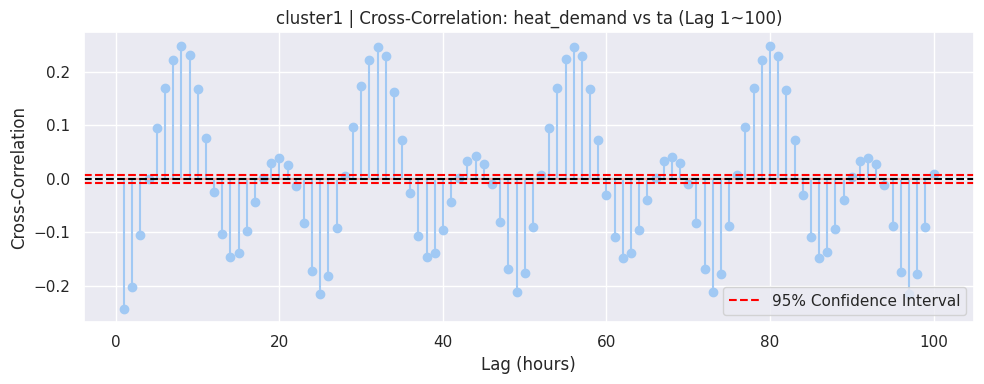

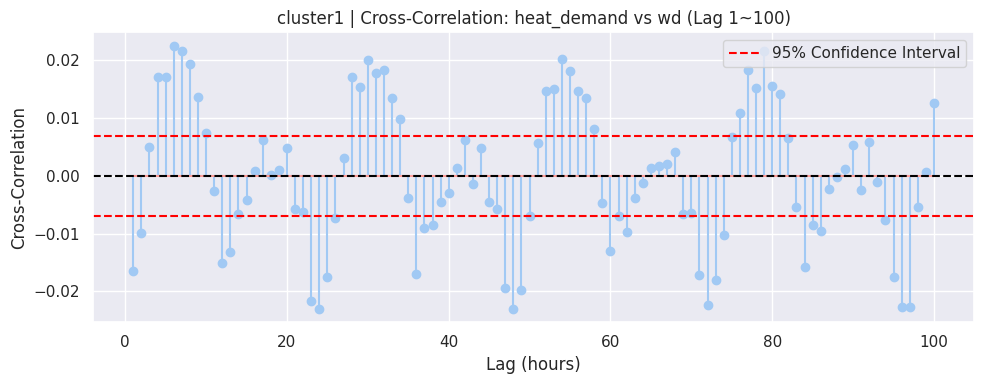

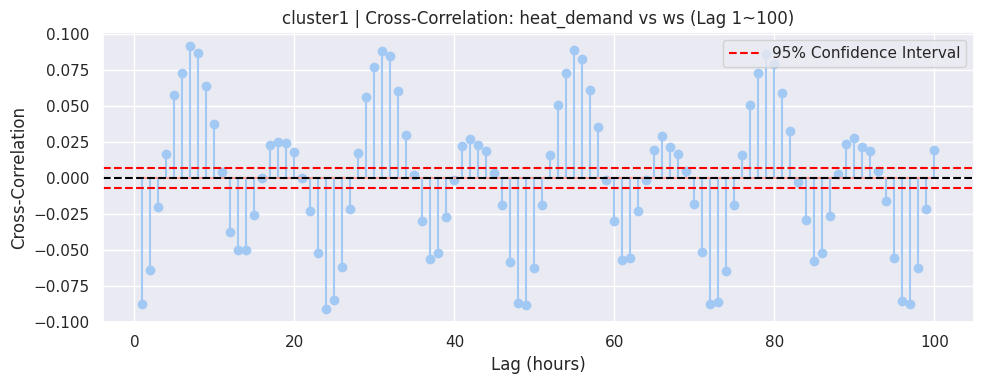

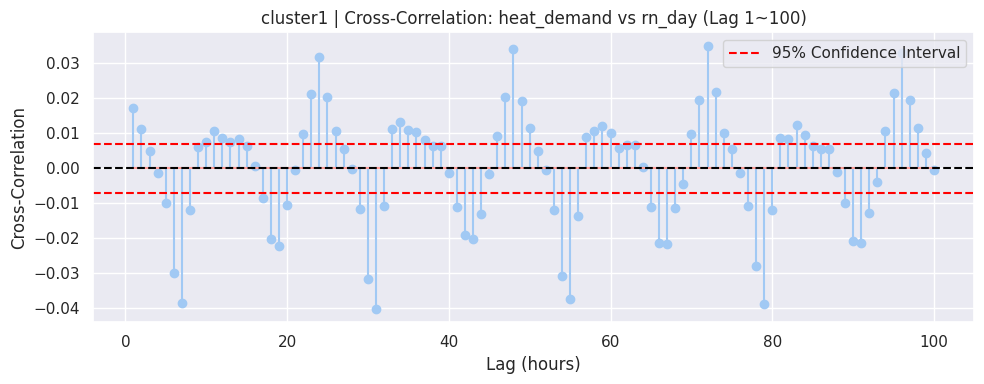

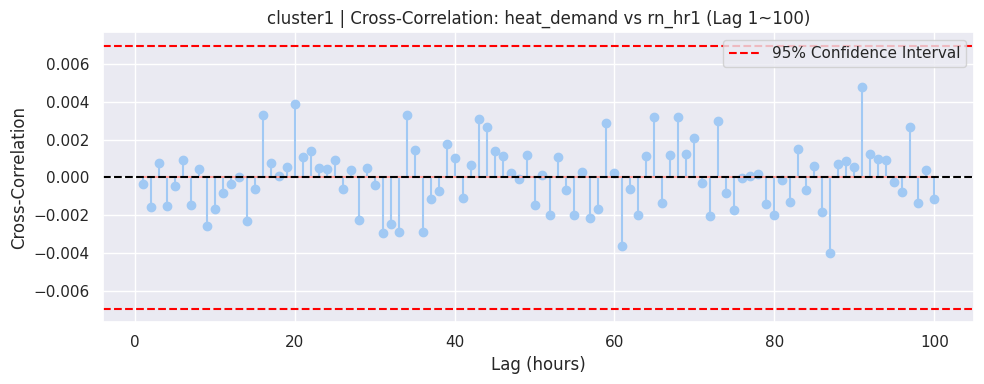

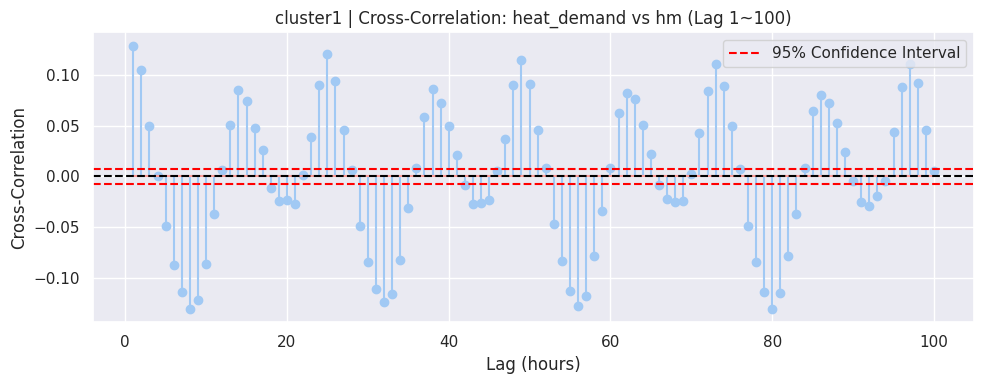

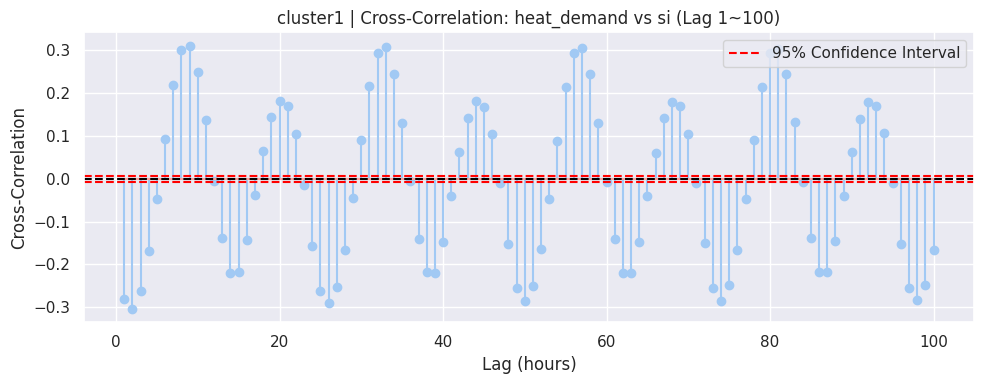

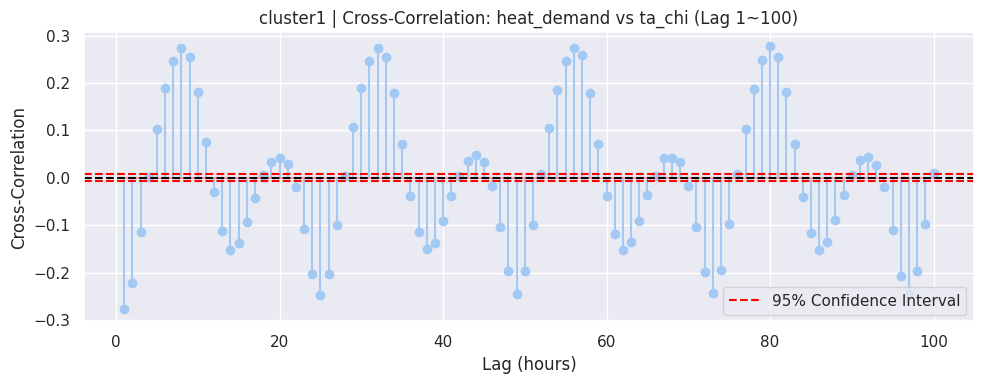

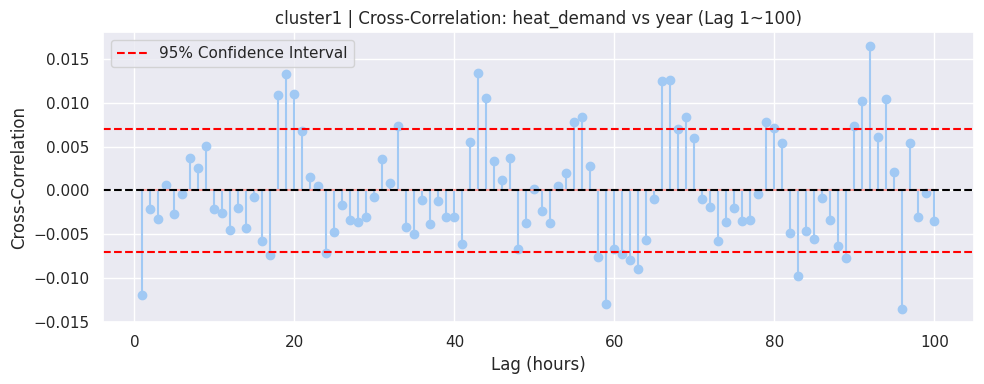

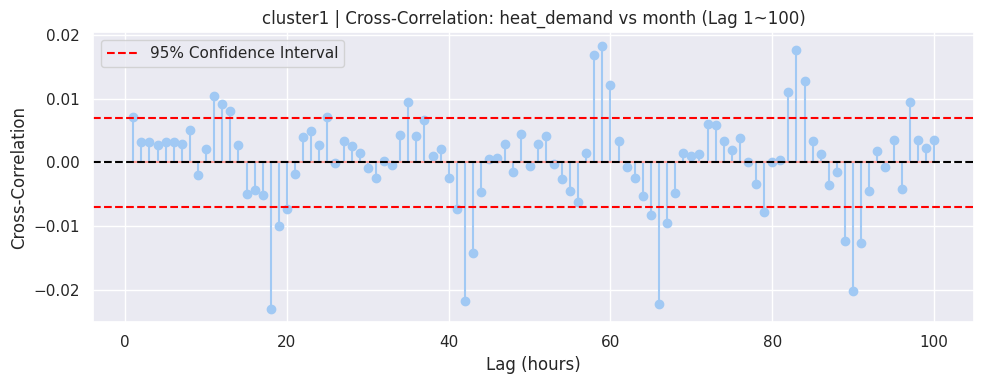

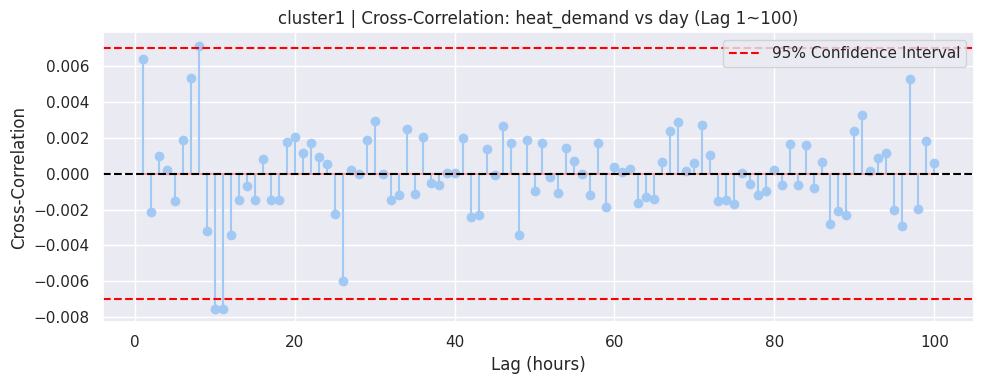

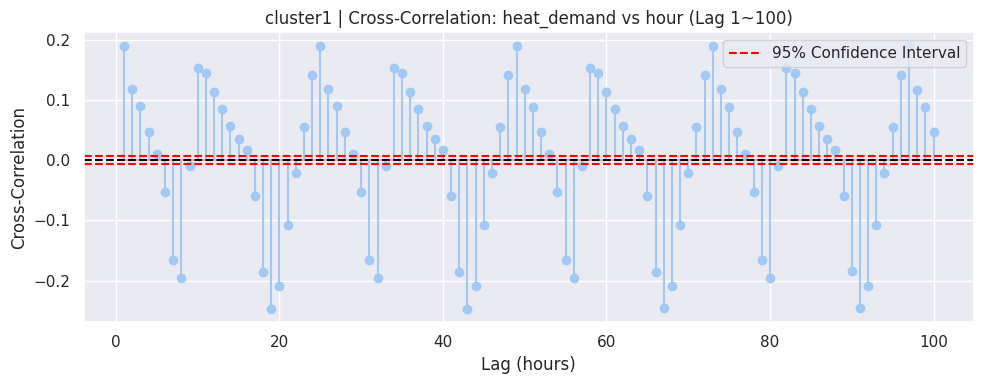

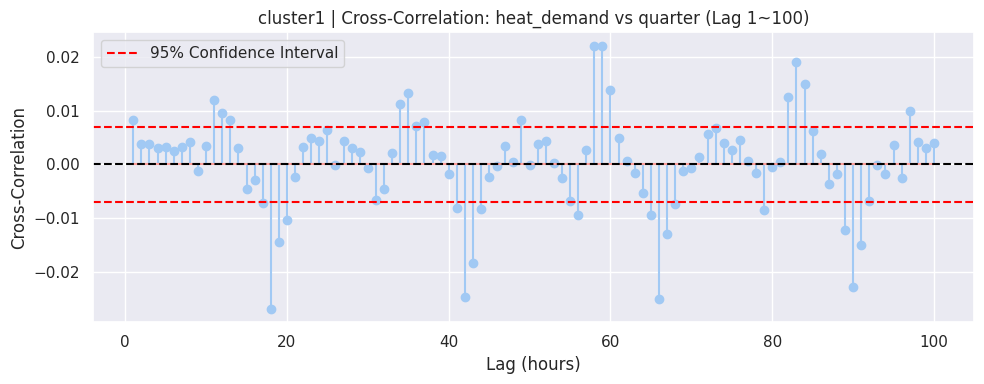

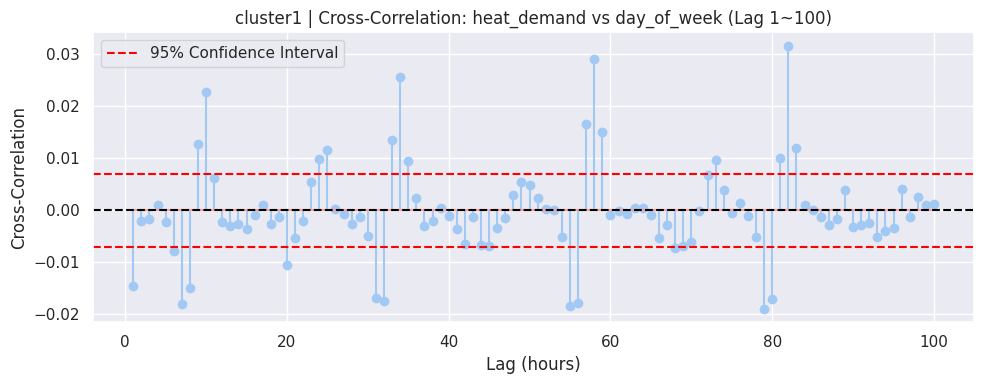

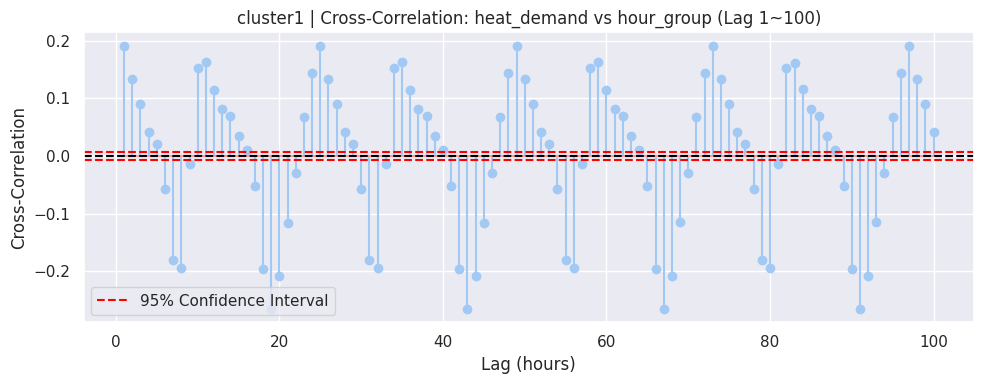

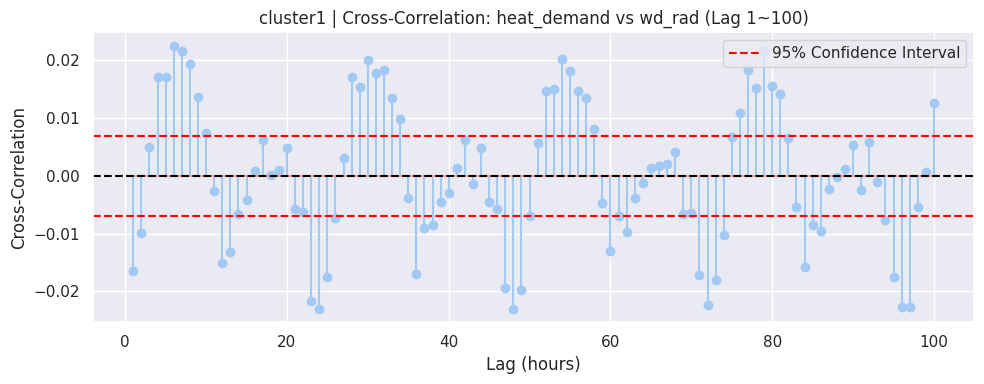

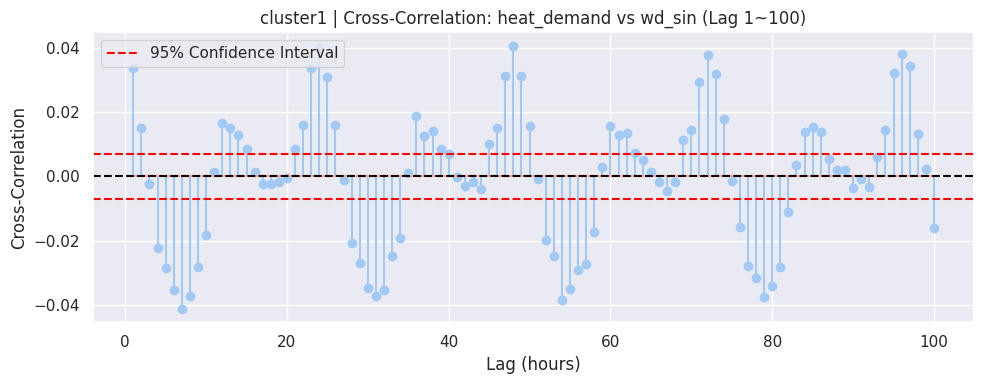

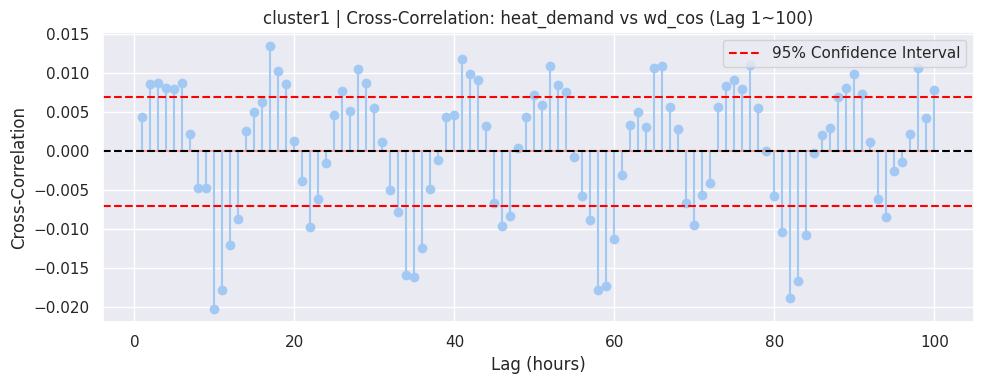

In [ ]:
from statsmodels.tsa.stattools import ccf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# datetime 처리 및 month 추출
df_train_cluster1['tm'] = pd.to_datetime(df_train_cluster1['tm'])
if 'month' not in df_train_cluster1.columns:
    df_train_cluster1['month'] = df_train_cluster1['tm'].dt.month

# 숫자형 변수만 추출
numeric_cols = df_train_cluster1.select_dtypes(include=[np.number]).columns

# CCF 계산 및 시각화 함수
def plot_ccf_by_season(df, label):
    target_var = 'heat_demand'
    variables = [col for col in df.columns if col != target_var and col in numeric_cols]

    # 1차 차분
    target_diff = df[target_var].diff().dropna()
    max_lag = 100

    for var in variables:
        var_diff = df[var].diff().dropna()

        # 길이 맞추기
        min_len = min(len(target_diff), len(var_diff))
        x = target_diff[:min_len]
        y = var_diff[:min_len]

        # CCF 계산
        ccf_vals_full = ccf(x, y)
        ccf_vals = ccf_vals_full[1:max_lag + 1]
        lags_range = np.arange(1, max_lag + 1)

        # 신뢰구간
        N = len(x)
        conf_level = 1.96 / np.sqrt(N)

        # 시각화
        plt.figure(figsize=(10, 4))
        plt.stem(lags_range, ccf_vals)
        plt.title(f"{label} | Cross-Correlation: {target_var} vs {var} (Lag 1~{max_lag})")
        plt.xlabel("Lag (hours)")
        plt.ylabel("Cross-Correlation")
        plt.grid(True)
        plt.axhline(0, color='black', linestyle='--')
        plt.axhline(conf_level, color='red', linestyle='--', label='95% Confidence Interval')
        plt.axhline(-conf_level, color='red', linestyle='--')
        plt.legend()
        plt.tight_layout()
        plt.show()

# 실행
plot_ccf_by_season(df_train_cluster1, 'cluster1')


## 2. stl 분해 후 residual 끼리 ccf plot 그리기
- 각 지역의 heat_demand 시계열은 유사한 패턴을 보이며, 지역 간의 구조적인 차이가 크지 않음
- 분석의 목적은 전체 heat_demand에 대한 lag 특성을 파악하는 것이며, 이후 모델링 단계에서도 지역별이 아닌 여름/비여름으로 구분하여 하나의 모델을 학습할 예정임
- 따라서 4개 지역의 데이터를 하나의 시계열로 간주하여 통합한 후, 전체 흐름을 기반으로 STL 분해를 수행하였음
- 이 과정을 통해 트렌드와 계절성의 구조적 특성을 먼저 파악하고, 이후 필요 시 지역별로 세분화하여 분석을 확장할 수 있음

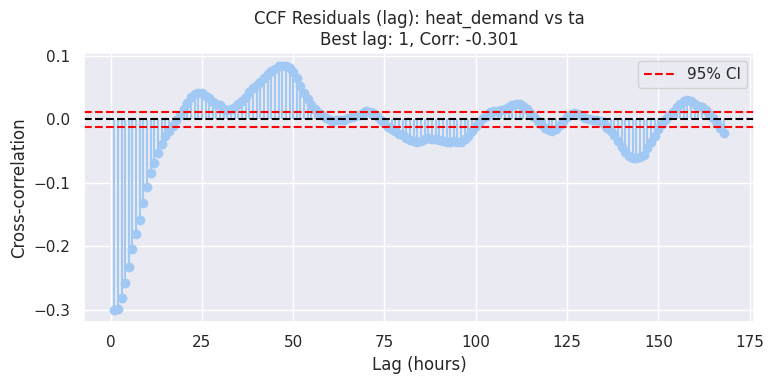

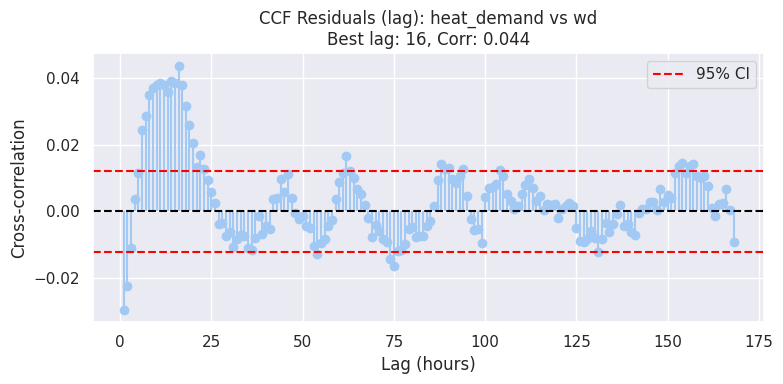

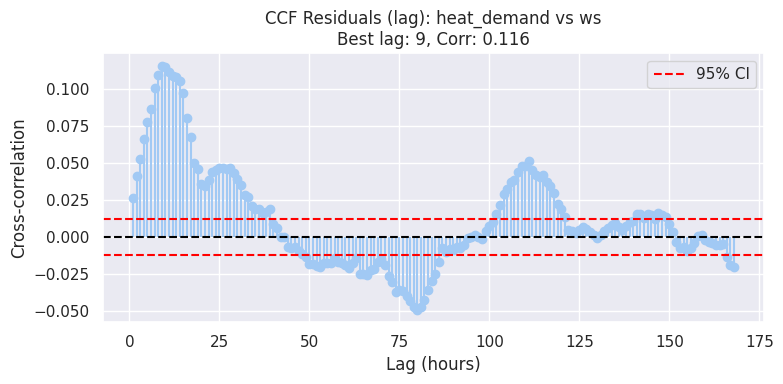

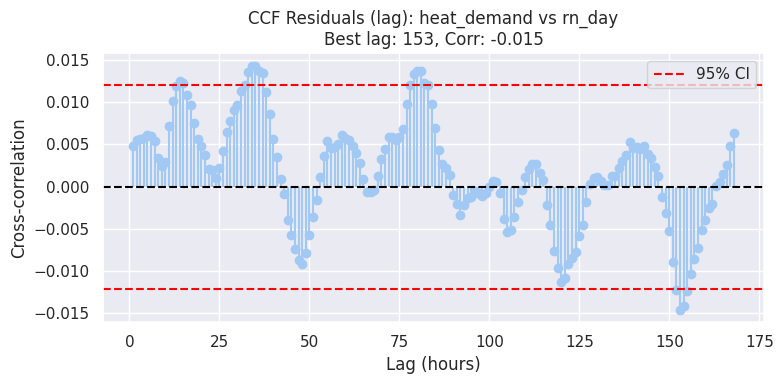

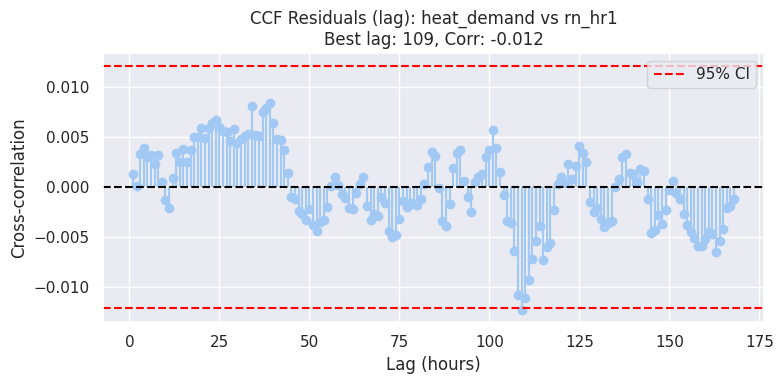

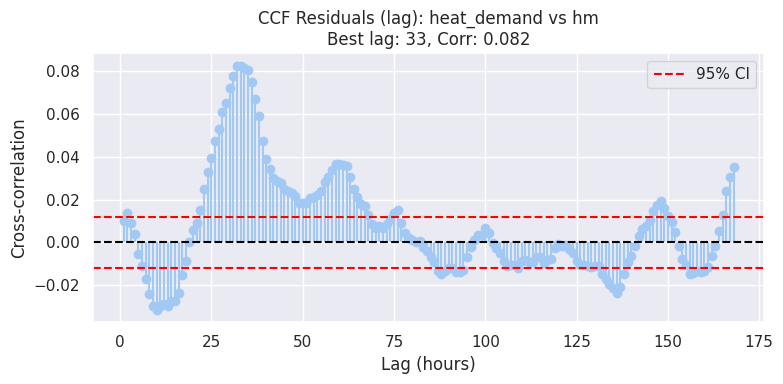

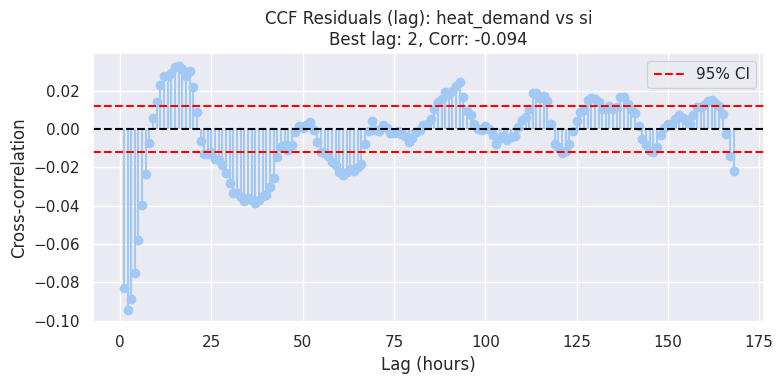

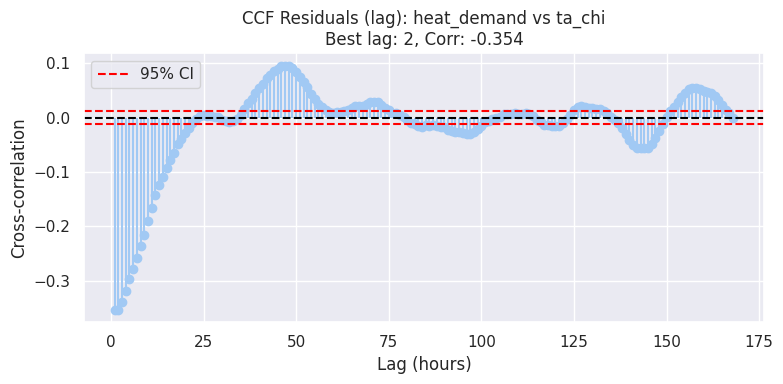

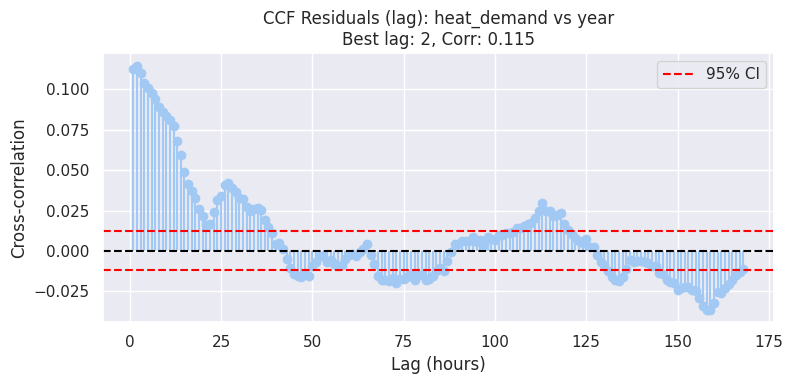

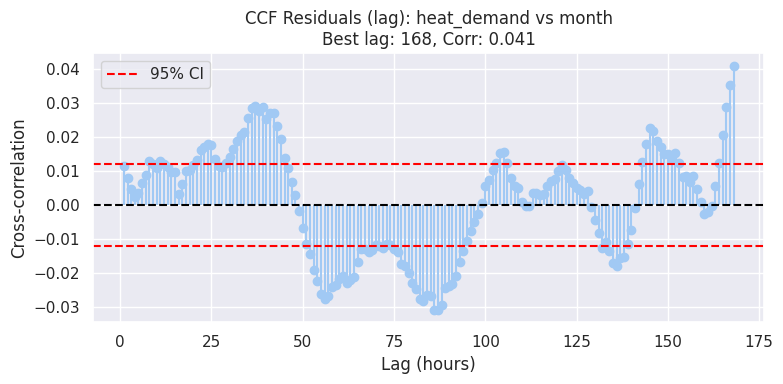

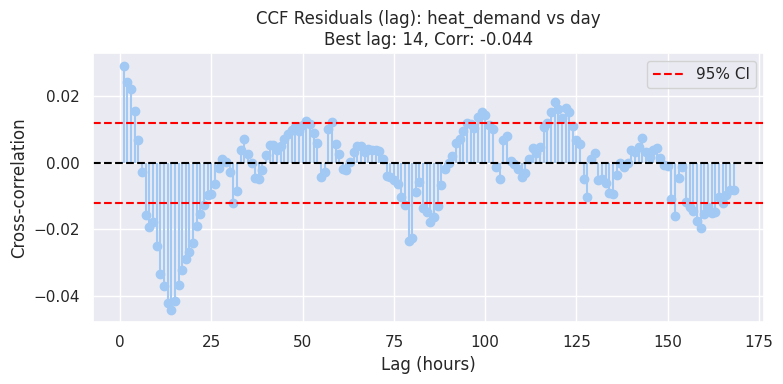

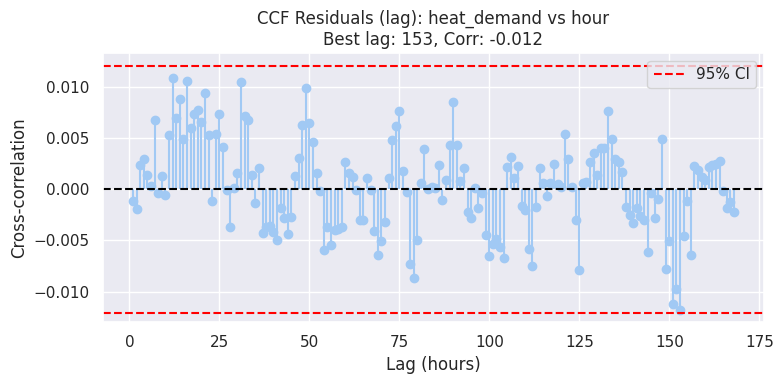

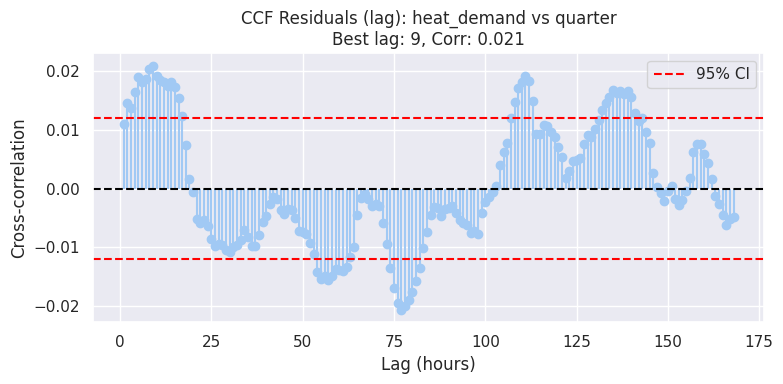

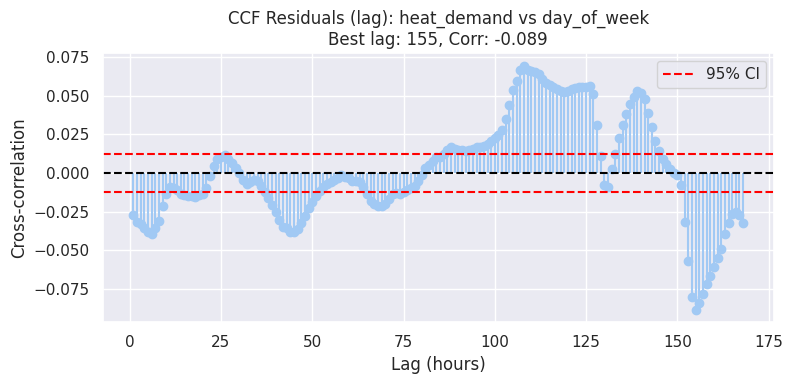

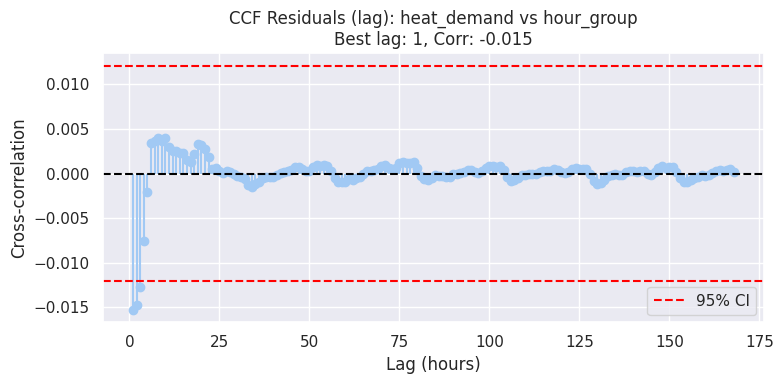

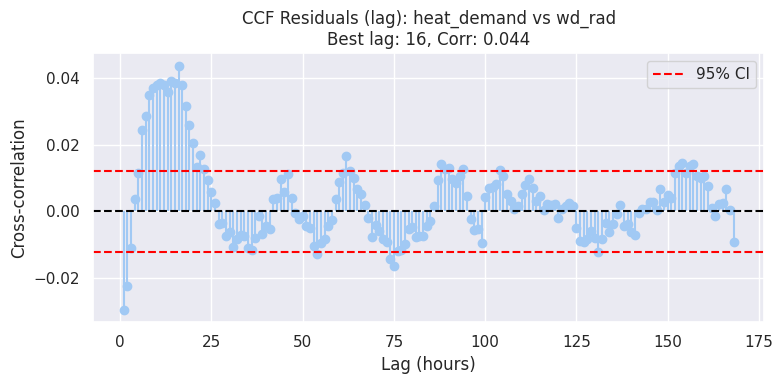

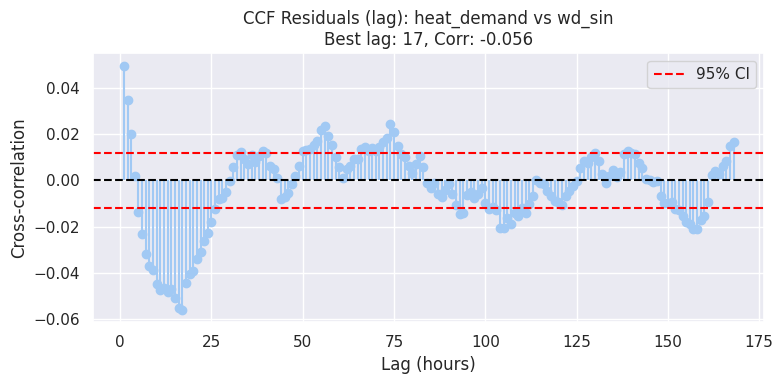

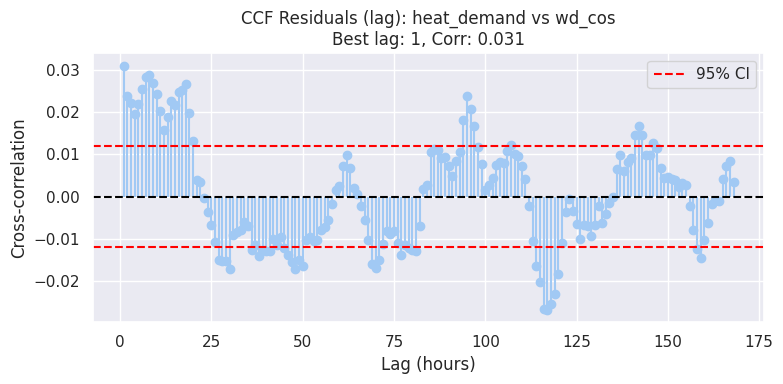

lags: {'ta': {'best_lag': np.int64(1), 'ccf_value': np.float64(-0.30082357987557423)}, 'wd': {'best_lag': np.int64(16), 'ccf_value': np.float64(0.04370505897719742)}, 'ws': {'best_lag': np.int64(9), 'ccf_value': np.float64(0.1158893565997545)}, 'rn_day': {'best_lag': np.int64(153), 'ccf_value': np.float64(-0.014633924534401615)}, 'rn_hr1': {'best_lag': np.int64(109), 'ccf_value': np.float64(-0.012293104076966925)}, 'hm': {'best_lag': np.int64(33), 'ccf_value': np.float64(0.0822937898444787)}, 'si': {'best_lag': np.int64(2), 'ccf_value': np.float64(-0.09442662510448178)}, 'ta_chi': {'best_lag': np.int64(2), 'ccf_value': np.float64(-0.35407643286471774)}, 'year': {'best_lag': np.int64(2), 'ccf_value': np.float64(0.11478587722338873)}, 'month': {'best_lag': np.int64(168), 'ccf_value': np.float64(0.04094165072310687)}, 'day': {'best_lag': np.int64(14), 'ccf_value': np.float64(-0.04426413305887915)}, 'hour': {'best_lag': np.int64(153), 'ccf_value': np.float64(-0.011800542123658376)}, 'quart

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import ccf
import matplotlib.pyplot as plt


df = df_train_cluster1.copy()
df['tm'] = pd.to_datetime(df['tm'])

# 숫자형 컬럼만 평균 내기
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_hourly = df.groupby(['tm'])[numeric_cols].mean().reset_index()
df_hourly = df_hourly.set_index('tm')

target_var = 'heat_demand'
variables = [col for col in df_hourly.select_dtypes(include=[np.number]).columns if col not in [target_var, 'is_summer']]

max_lag = 168

def stl_decompose_and_get_residuals(series):
    stl = STL(series, period=24, robust=True)
    res = stl.fit()
    return res.resid

def find_best_lag_and_plot_residuals(df_group, group_name):
    results = {}

    target_resid = stl_decompose_and_get_residuals(df_group[target_var].dropna())

    for var in variables:
        var_resid = stl_decompose_and_get_residuals(df_group[var].dropna())

        min_len = min(len(target_resid), len(var_resid))
        x = target_resid[:min_len]
        y = var_resid[:min_len]

        ccf_vals = ccf(x, y)[:max_lag+1]
        ccf_vals_lags = ccf_vals[1:]

        best_lag = np.argmax(np.abs(ccf_vals_lags)) + 1
        best_corr = ccf_vals_lags[best_lag-1]

        results[var] = {'best_lag': best_lag, 'ccf_value': best_corr}

        plt.figure(figsize=(8,4))
        lags = np.arange(1, max_lag+1)
        plt.stem(lags, ccf_vals_lags, basefmt=" ")
        plt.axhline(0, color='black', linestyle='--')
        N = len(x)
        conf_level = 1.96 / np.sqrt(N)
        plt.axhline(conf_level, color='red', linestyle='--', label='95% CI')
        plt.axhline(-conf_level, color='red', linestyle='--')
        plt.title(f"CCF Residuals ({group_name}): heat_demand vs {var}\nBest lag: {best_lag}, Corr: {best_corr:.3f}")
        plt.xlabel("Lag (hours)")
        plt.ylabel("Cross-correlation")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return results


lags = find_best_lag_and_plot_residuals(df_hourly, "lag")

print("lags:", lags)


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import ccf

# ―――― 기본 설정 ――――
target_var = 'heat_demand'   # 타깃 변수
max_lag   = 168              # 1주일(24*7) lag까지 탐색
alpha     = 0.05             # 유의수준(95 % → 0.05)
extra_tol = 0.05             # 유의선 ±에 추가 허용치(실질적 영향 필터)

# ① STL 잔차 구하는 함수 -------------------------------------------------
def stl_resid(series, period=24):
    """STL 분해 후 잔차 반환"""
    res = STL(series, period=period, robust=True).fit()
    return res.resid

# ② 변수별 lag 추천 함수 -------------------------------------------------
def get_sig_lags(x, y, max_lag=168, alpha=0.05, extra=0.05):
    """
    x: target residual (Series)
    y: variable residual (Series)
    반환: (선택한 lag 리스트, 선택한 lag에 대응하는 CCF 값 리스트)
    """
    n = min(len(x), len(y))
    if n == 0:
        return [], []

    c = ccf(x[:n], y[:n])[:max_lag+1][1:]     # lag1~max
    crit = 1.96 / np.sqrt(n) + extra          # 통계적 선 + 실질 여유
    idx  = np.where(np.abs(c) >= crit)[0] + 1 # 유의한 lag 번호

    # 겹치는 lag(±1h 이내)은 가장 |ccf| 큰 것 하나만 남김
    selected = []
    for k in idx:
        if not any(abs(k-s) <= 1 for s in selected):
            selected.append(k)
    return selected, c[[k-1 for k in selected]]

# ③ 전체 파이프라인 ------------------------------------------------------
def extract_best_lags(df, target='heat_demand', max_lag=168):
    df = df.copy()
    df['tm'] = pd.to_datetime(df['tm'])

    # 시계열 index로 변환 후 시간별 평균(※ 필요 없으면 주석 처리)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df_hourly = (
        df.groupby('tm')[num_cols].mean()
          .sort_index()
    )

    variables = [c for c in df_hourly.columns if c not in [target, 'is_summer']]

    # STL 잔차
    target_resid = stl_resid(df_hourly[target].dropna())

    lag_dict = {}
    for var in variables:
        var_resid = stl_resid(df_hourly[var].dropna())
        lags, cvals = get_sig_lags(target_resid, var_resid,
                                   max_lag=max_lag, alpha=alpha, extra=extra_tol)
        lag_dict[var] = {'lags': lags, 'ccf_vals': cvals}

    return lag_dict

# ④ 사용 예 --------------------------------------------------------------
lags_by_var = extract_best_lags(df_train_cluster1)
print(lags_by_var)


{'ta': {'lags': [np.int64(1), np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(11), np.int64(42), np.int64(44), np.int64(46), np.int64(48), np.int64(50)], 'ccf_vals': array([-0.30082358, -0.28162089, -0.23239445, -0.18132237, -0.13152149,
       -0.08494921,  0.06600729,  0.07619981,  0.08484488,  0.08443181,
        0.07460328])}, 'wd': {'lags': [], 'ccf_vals': array([], dtype=float64)}, 'ws': {'lags': [np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16)], 'ccf_vals': array([0.0664352 , 0.08691819, 0.10934194, 0.11483742, 0.10916446,
       0.10517358, 0.08040318])}, 'rn_day': {'lags': [], 'ccf_vals': array([], dtype=float64)}, 'rn_hr1': {'lags': [], 'ccf_vals': array([], dtype=float64)}, 'hm': {'lags': [np.int64(29), np.int64(31), np.int64(33), np.int64(35), np.int64(37)], 'ccf_vals': array([0.06497788, 0.07752512, 0.08229379, 0.08039153, 0.06691489])}, 'si': {'lags': [np.int64(1), np.int64(3)], 'ccf_vals': array([-0.08312686, -0.

In [ ]:
from itertools import groupby
from operator import itemgetter

def compress_lags(lag_list, min_run=3):
    """
    lag_list : [1,3,4,5,6,24]  같은 정수 리스트
    min_run  : 연속 구간을 range() 로 표시할 최소 길이
    반환값   : ['list(range(3,7))', 1, 24] 처럼 range 문자열+개별값
    """
    lag_list = sorted(int(l) for l in lag_list)
    compressed = []

    for _, grp in groupby(enumerate(lag_list), lambda t: t[1]-t[0]):
        seq = list(map(itemgetter(1), grp))        # 연속 구간
        if len(seq) >= min_run:
            compressed.append(f"list(range({seq[0]}, {seq[-1]+1}))")
        else:
            compressed.extend(seq)
    return compressed

# ――― lags_by_var → dict 형태로 변환 ―――
lag_spec = {}
for var, info in lags_by_var.items():
    lags = [int(l) for l in info['lags']]
    # 연속 구간 3개 이상이면 range() 로, 아니면 그대로
    lag_spec[var] = compress_lags(lags)

# ――― 보기 좋게 코드 형식으로 출력 ―――
print("lag_dict = {")
for k, v in lag_spec.items():
    # range() 문자열은 그대로, 숫자는 그대로 보이도록 join
    pieces = [s if isinstance(s, str) else str(s) for s in v]
    joined = ", ".join(pieces) if pieces else ""
    print(f"    '{k}': [{joined}],")
print("}")


lag_dict = {
    'ta': [1, 3, 5, 7, 9, 11, 42, 44, 46, 48, 50],
    'wd': [],
    'ws': [4, 6, 8, 10, 12, 14, 16],
    'rn_day': [],
    'rn_hr1': [],
    'hm': [29, 31, 33, 35, 37],
    'si': [1, 3],
    'ta_chi': [1, 3, 5, 7, 9, 11, 13, 15, 17, 41, 43, 45, 47, 49, 51],
    'year': [1, 3, 5, 7, 9, 11, 13],
    'month': [],
    'day': [],
    'hour': [],
    'quarter': [],
    'day_of_week': [107, 109, 111, 154, 156, 158],
    'hour_group': [],
    'wd_rad': [],
    'wd_sin': [],
    'wd_cos': [],
}
